In [16]:
img_rgb[:3,:3,:]

array([[[17, 34, 15],
        [15, 34, 12],
        [13, 33,  8]],

       [[ 4, 21,  2],
        [ 1, 19,  0],
        [ 9, 29,  4]],

       [[12, 27,  8],
        [ 0, 17,  0],
        [15, 35, 10]]], dtype=uint8)

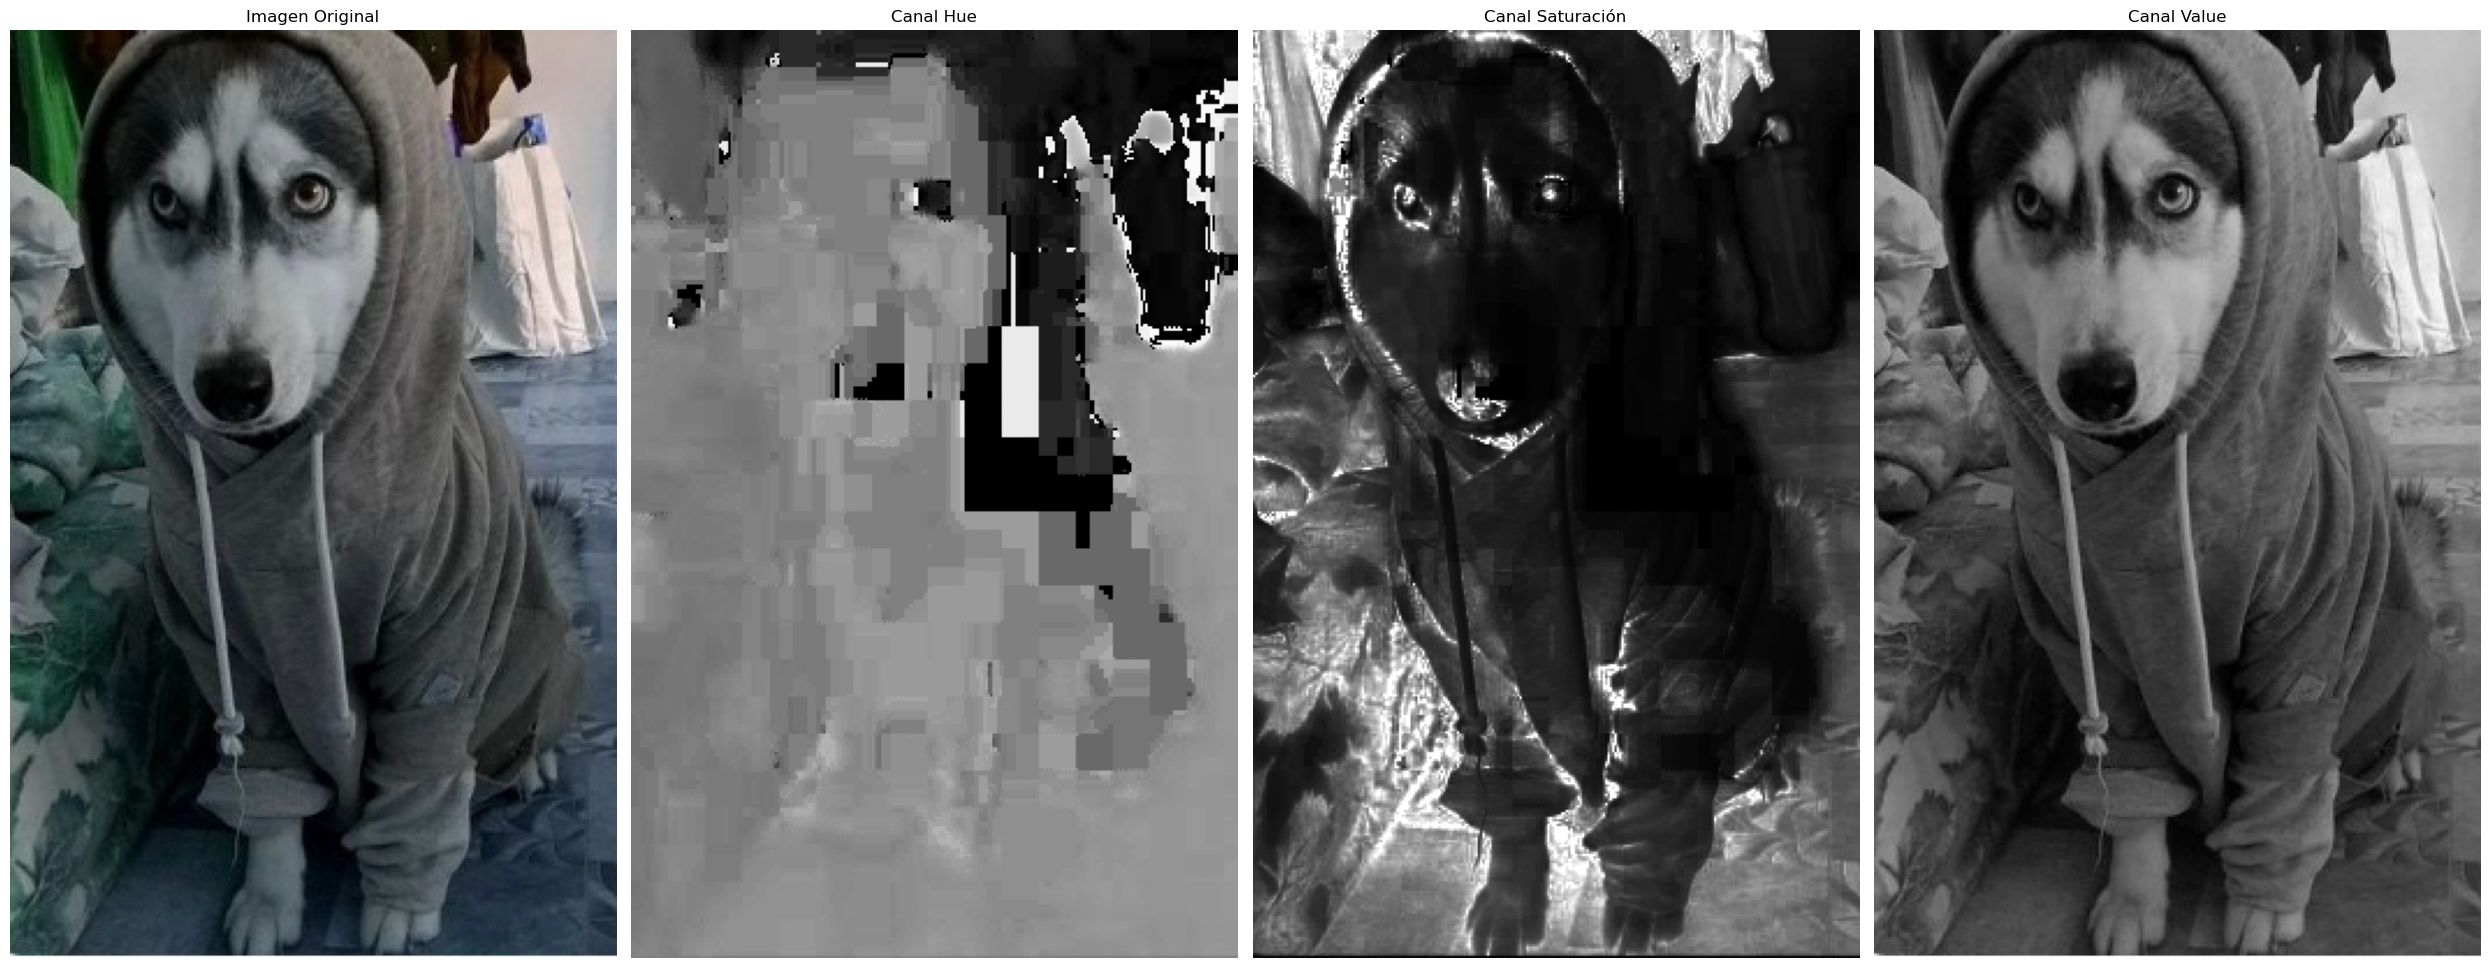

In [13]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Leer imagen
jpg = cv2.imread('jpg.jpg')

if jpg is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

# Convertir BGR (OpenCV) a RGB
img = cv2.cvtColor(jpg, cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32) / 255
    new_img = np.zeros_like(img)

    maxChannel = np.argmax(img, axis=2)
    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)

    # Value
    new_img[..., 2] = maxValue

    # Saturation
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i, j] == 0:
                new_img[i, j, 1] = 0
            else:
                new_img[i, j, 1] = (maxValue[i, j] - minValue[i, j]) / maxValue[i, j]

    # Hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):

            if maxValue[i, j] == minValue[i, j]:
                new_img[i, j, 0] = 0

            elif maxChannel[i, j] == 0:  # R
                new_img[i, j, 0] = 60 * (
                    (img[i, j, 1] - img[i, j, 2]) /
                    (maxValue[i, j] - minValue[i, j])
                )

            elif maxChannel[i, j] == 1:  # G
                new_img[i, j, 0] = 120 + 60 * (
                    (img[i, j, 2] - img[i, j, 0]) /
                    (maxValue[i, j] - minValue[i, j])
                )

            elif maxChannel[i, j] == 2:  # B
                new_img[i, j, 0] = 240 + 60 * (
                    (img[i, j, 0] - img[i, j, 1]) /
                    (maxValue[i, j] - minValue[i, j])
                )

            if new_img[i, j, 0] < 0:
                new_img[i, j, 0] += 360

    return new_img


# Convertir imagen
hsv_img = RGB2HSV(img)

# Mostrar resultados
fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen Original')
axs[0].axis('off')

axs[1].imshow(hsv_img[..., 0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')
axs[1].axis('off')

axs[2].imshow(hsv_img[..., 1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')
axs[2].axis('off')

axs[3].imshow(hsv_img[..., 2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')
axs[3].axis('off')

plt.tight_layout()
plt.show()

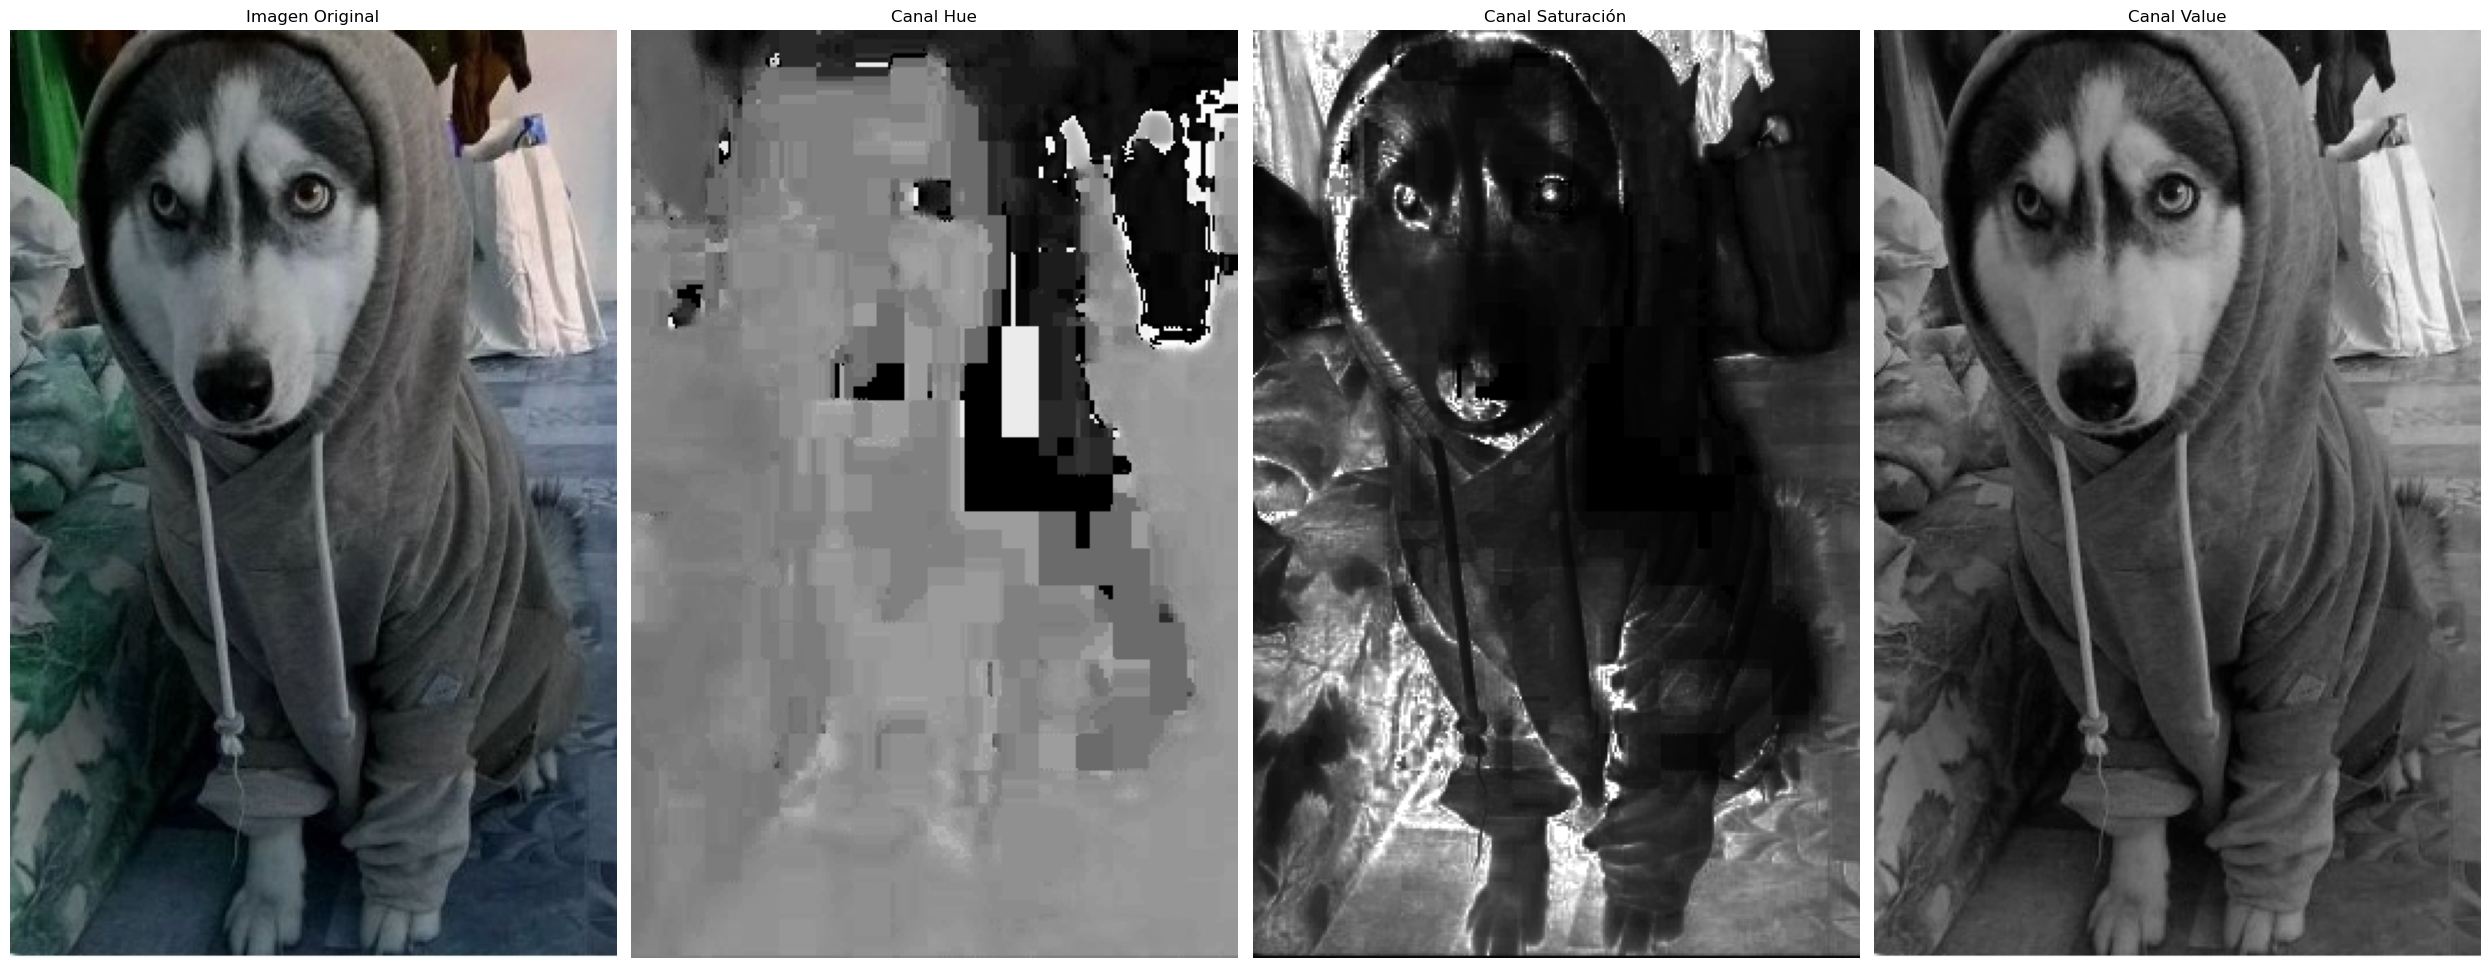

In [23]:
hsv_img = cv2.cvtColor(img,cv2.COLOR_RGB2HSV)
fig, axs = plt.subplots(1, 4, figsize=(25, 10))

axs[0].imshow(img)
axs[0].set_title('Imagen Original')
axs[0].axis('off')

axs[1].imshow(hsv_img[..., 0], cmap='gray', vmin=0, vmax=179)
axs[1].set_title('Canal Hue')
axs[1].axis('off')

axs[2].imshow(hsv_img[..., 1], cmap='gray', vmin=0, vmax=255)
axs[2].set_title('Canal Saturación')
axs[2].axis('off')

axs[3].imshow(hsv_img[..., 2], cmap='gray', vmin=0, vmax=255)
axs[3].set_title('Canal Value')
axs[3].axis('off')

plt.tight_layout()
plt.show()



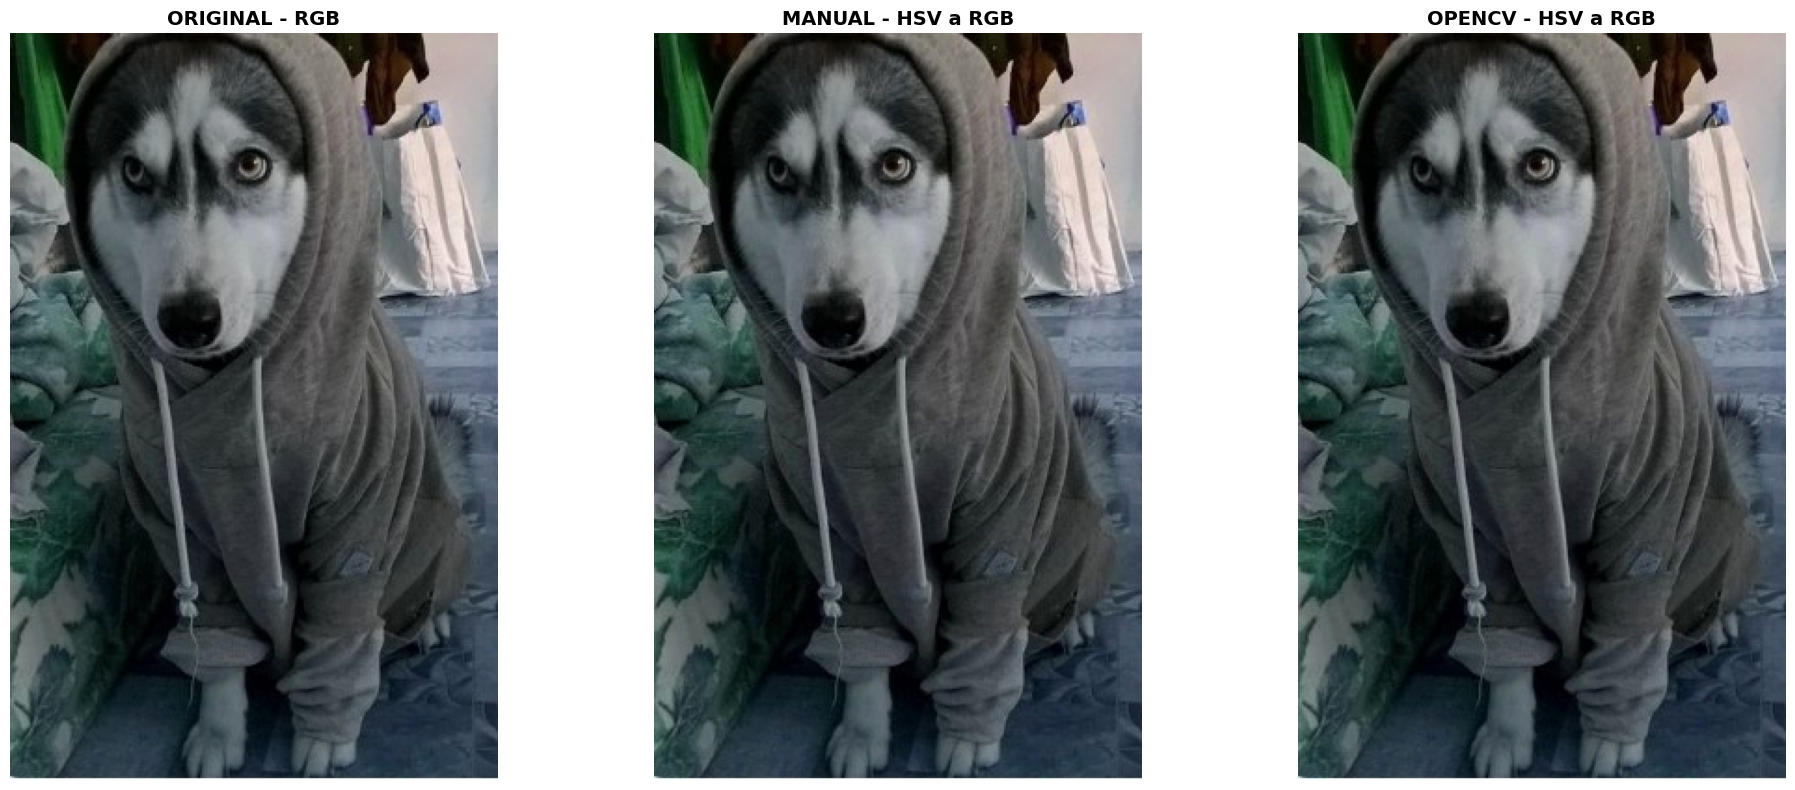

In [37]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
def hsv_to_rgb_manual(hsv_image):
    h = hsv_image[:, :, 0].astype(np.float32) * 2.0  # H: 0-360
    s = hsv_image[:, :, 1].astype(np.float32) / 255.0  # S: 0-1
    v = hsv_image[:, :, 2].astype(np.float32) / 255.0  # V: 0-1
    height, width = h.shape
    c = v * s
    m = v - c
    h_norm = h / 60.0
    h_mod = h_norm % 2
    x = c * (1 - np.abs(h_mod - 1))
    rp = np.zeros_like(c)
    gp = np.zeros_like(c)
    bp = np.zeros_like(c)
    for i in range(height):
        for j in range(width):
            h_val = h[i, j]
            if h_val < 60:
                rp[i, j] = c[i, j]
                gp[i, j] = x[i, j]
                bp[i, j] = 0
            elif h_val < 120:
                rp[i, j] = x[i, j]
                gp[i, j] = c[i, j]
                bp[i, j] = 0
            elif h_val < 180:
                rp[i, j] = 0
                gp[i, j] = c[i, j]
                bp[i, j] = x[i, j]
            elif h_val < 240:
                rp[i, j] = 0
                gp[i, j] = x[i, j]
                bp[i, j] = c[i, j]
            elif h_val < 300:
                rp[i, j] = x[i, j]
                gp[i, j] = 0
                bp[i, j] = c[i, j]
            else:
                rp[i, j] = c[i, j]
                gp[i, j] = 0
                bp[i, j] = x[i, j]
    r = (rp + m) * 255
    g = (gp + m) * 255
    b = (bp + m) * 255
    rgb = np.stack([r, g, b], axis=2)
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)
    return rgb
img_bgr = cv2.imread('jpg.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
img_manual = hsv_to_rgb_manual(img_hsv)
img_opencv = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

axs[0].imshow(img_rgb)
axs[0].set_title("ORIGINAL - RGB", fontsize=14, fontweight='bold')
axs[0].axis("off")

axs[1].imshow(img_manual)
axs[1].set_title("MANUAL - HSV a RGB", fontsize=14, fontweight='bold')
axs[1].axis("off")

axs[2].imshow(img_opencv)
axs[2].set_title("OPENCV - HSV a RGB", fontsize=14, fontweight='bold')
axs[2].axis("off")

plt.tight_layout()
plt.show()

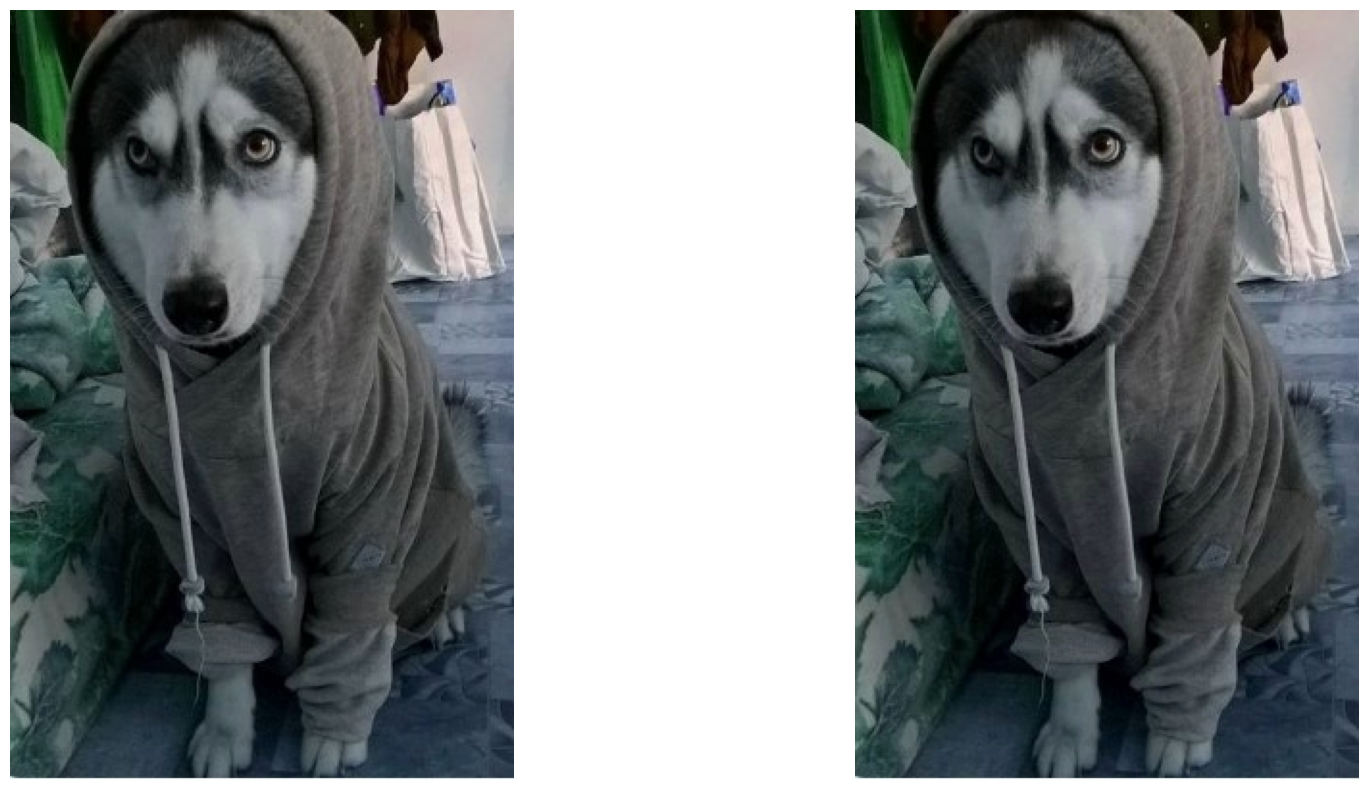

In [28]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
img_bgr = cv2.imread('jpg.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(img_rgb)
axs[0].axis("off")
img_hsv_to_rgb = cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB)
axs[1].imshow(img_hsv_to_rgb)
axs[1].axis("off")
plt.show()

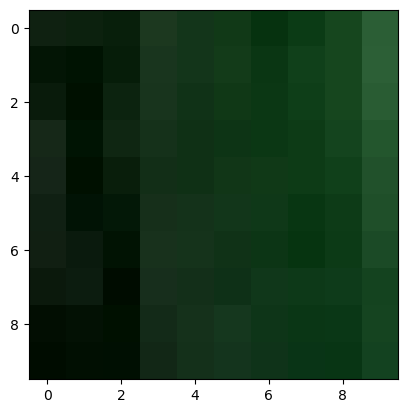

In [5]:
plt.imshow(img_rgb[:10,:10,:])

Text(0.5, 1.0, 'canal Rojo')

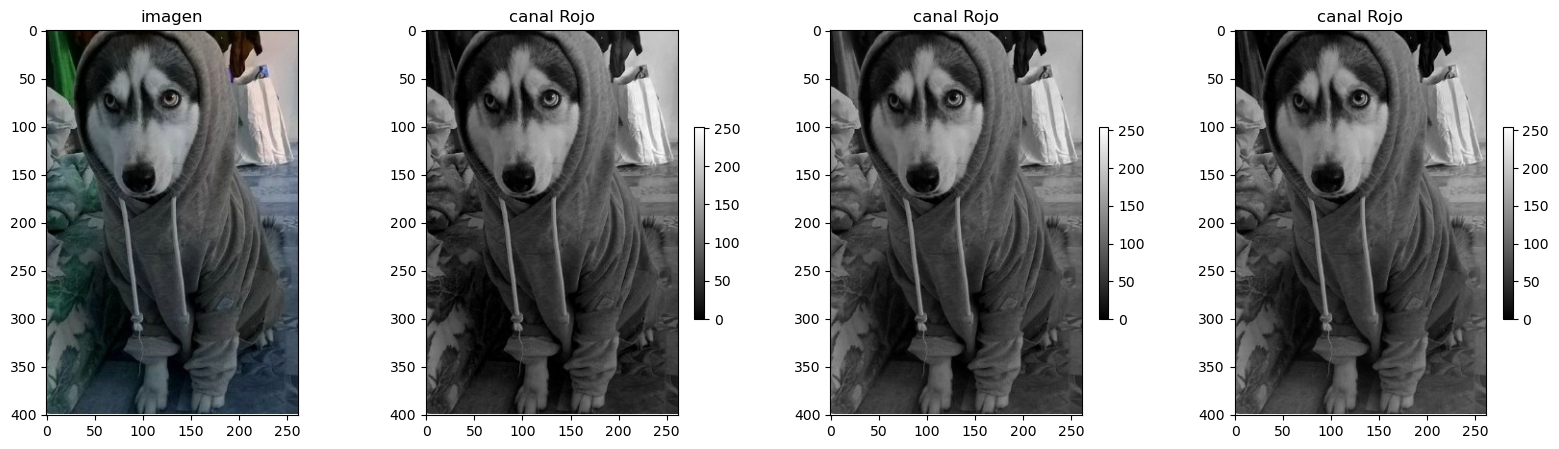

In [3]:
import cv2
import matplotlib.pyplot as plt

import numpy as np 
img=cv2.imread('jpg.jpg')
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

fig, axs =plt.subplots(1,4,figsize=(20,5))

axs[0].imshow(img_rgb)

axs[0].set_title('imagen')

fig_img=axs[1].imshow(img_rgb[...,0],cmap='gray')
fig.colorbar(fig_img,ax=axs[1],shrink=0.5)
axs[1].set_title('canal Rojo')



fig_img=axs[2].imshow(img_rgb[...,1],cmap='gray')
fig.colorbar(fig_img,ax=axs[2],shrink=0.5)
axs[2].set_title('canal Rojo')





fig_img=axs[3].imshow(img_rgb[...,2],cmap='gray')
fig.colorbar(fig_img,ax=axs[3],shrink=0.5)
axs[3].set_title('canal Rojo')

In [18]:
cv2.imwrite('jpg.jpg',img_rgb)
plt.imsave('imagen_nueva.png',cv2.cvtColor(img_rgb,cv2.COLOR_BGR2RGB))

profundidad del color : uint16


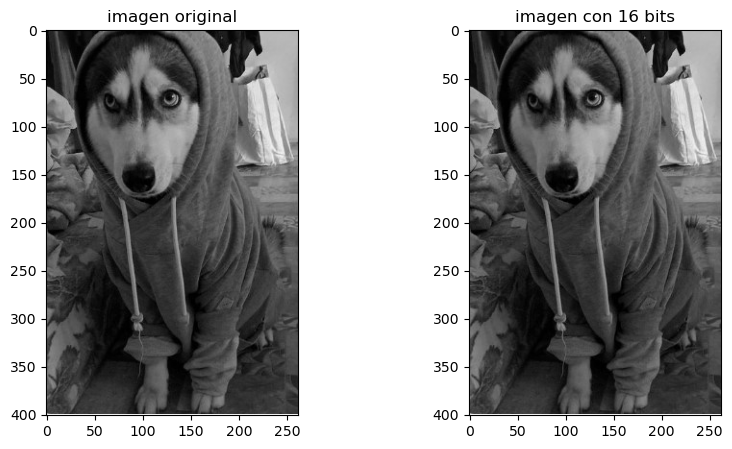

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np 
img=cv2.imread('jpg.jpg',cv2.IMREAD_GRAYSCALE)
#valores iniciales de profundidad de color
original= img.dtype

img16bits= np.uint16(img)
img_new=img16bits.dtype
print('profundidad del color :',img_new)

cv2.imwrite('jpg.jpg',img_rgb)
plt.imsave('imagen_nueva2.png',cv2.cvtColor(img_rgb,cv2.COLOR_BGR2RGB))

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('imagen original')
plt.imshow(img,cmap='gray')

plt.subplot(1,2,2)
plt.title('imagen con 16 bits')
plt.imshow(img,cmap='gray')


EJERICICIOS Para GENERaR UNa IMaGEN

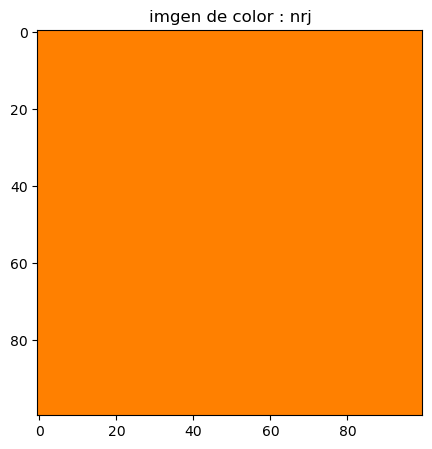

In [19]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize']=[10,5]
size_imagen=100
R=np.ones((size_imagen,size_imagen))*255
G=np.ones((size_imagen,size_imagen))*128
B=np.ones((size_imagen,size_imagen))*0

imagen=np.dstack((R,G,B))
imagen=np.array(imagen,dtype=int)

plt.figure()
plt.imshow(imagen)
plt.title('imgen de color : nrj')
plt.show()

PROCESANDO PRIMERA FOTOGRAFÍA...
----------------------------------------
✓ Imagen original BGR guardada como 'foto1_original_BGR.jpg'
✓ Imagen en escala de grises guardada como 'foto1_grises.jpg'


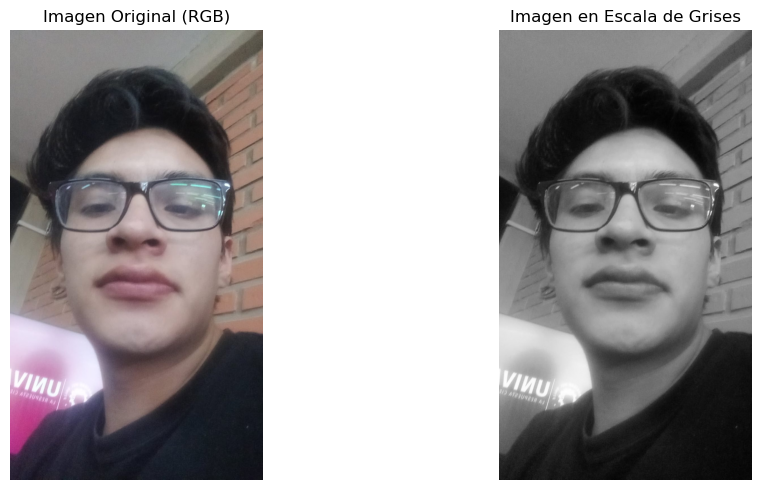

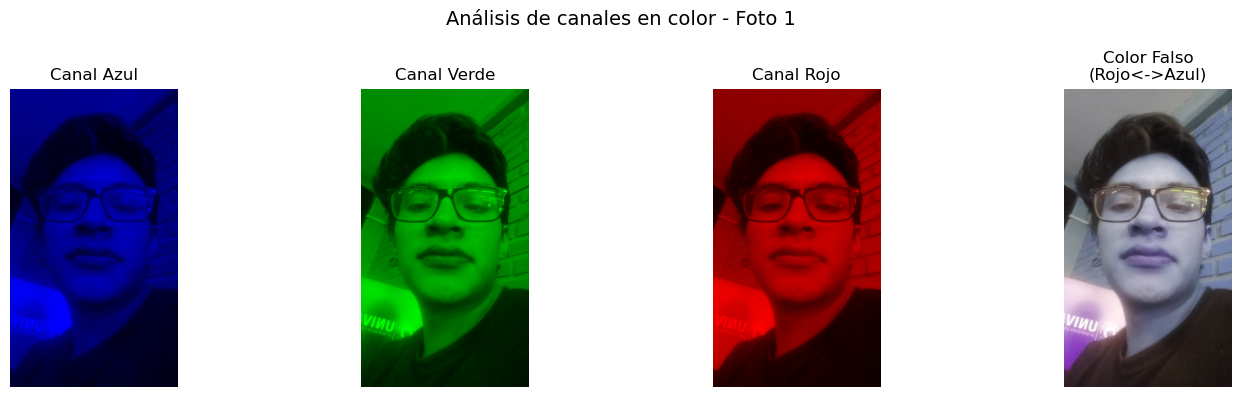

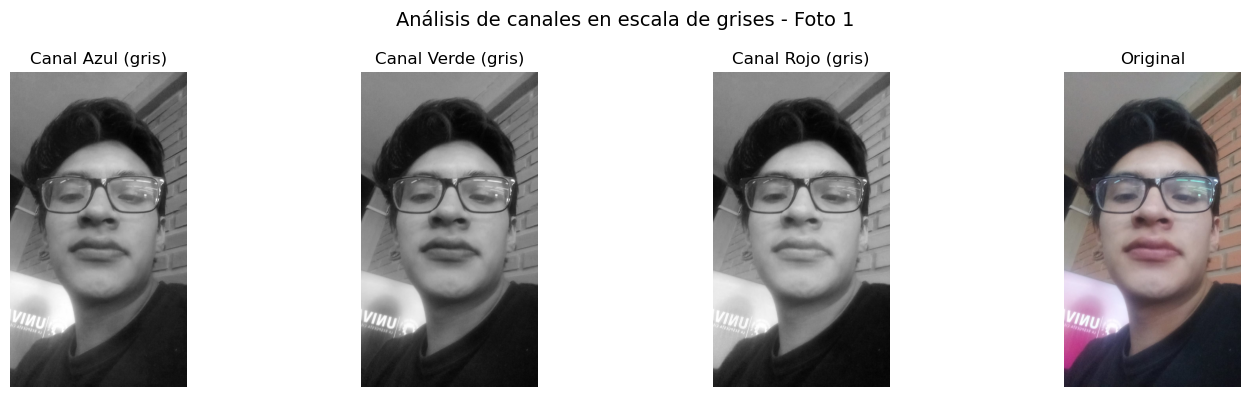


PROCESANDO SEGUNDA FOTOGRAFÍA...
----------------------------------------
✓ Imagen original BGR guardada como 'foto2_original_BGR.jpg'
✓ Imagen en escala de grises guardada como 'foto2_grises.jpg'


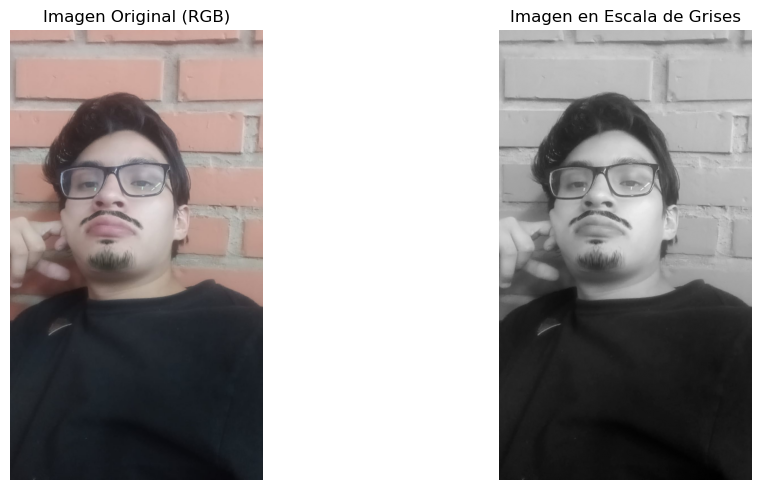

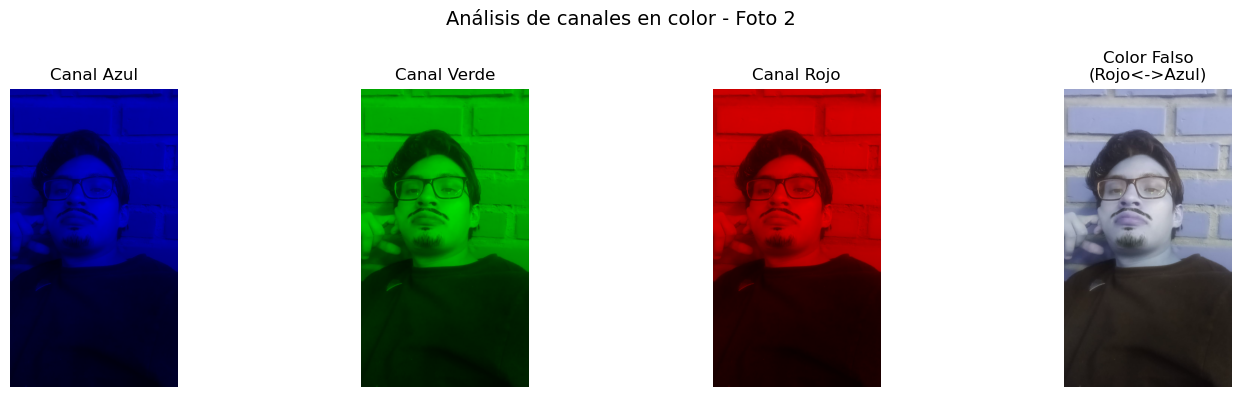

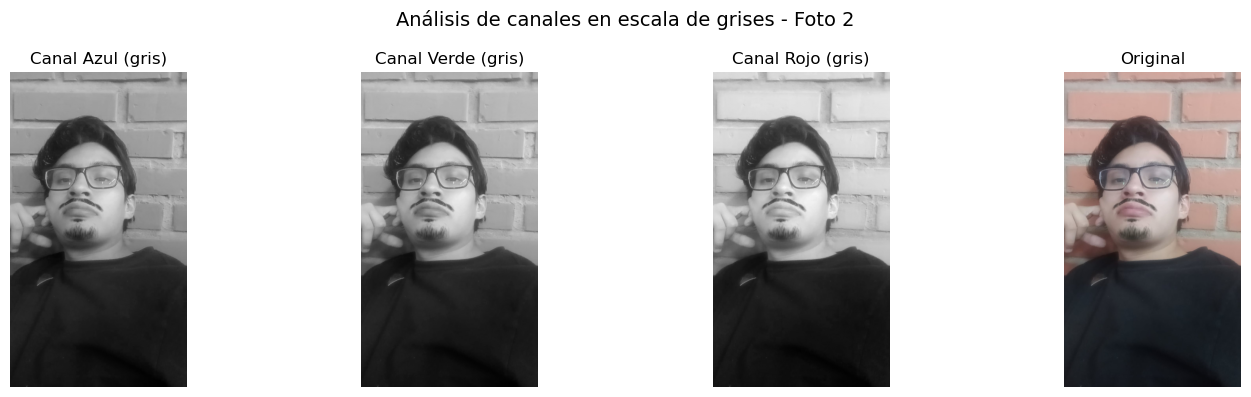


PROCESANDO TERCERA FOTOGRAFÍA...
----------------------------------------
✓ Imagen original BGR guardada como 'foto3_original_BGR.jpg'
✓ Imagen en escala de grises guardada como 'foto3_grises.jpg'


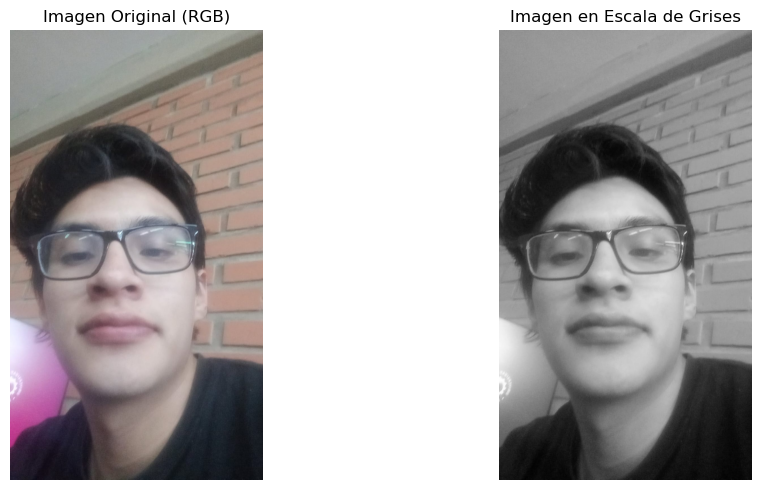

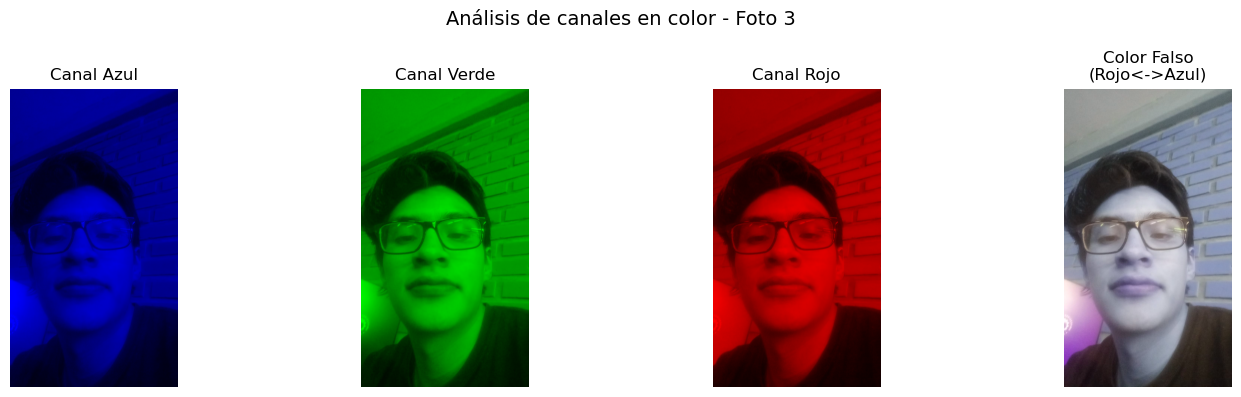

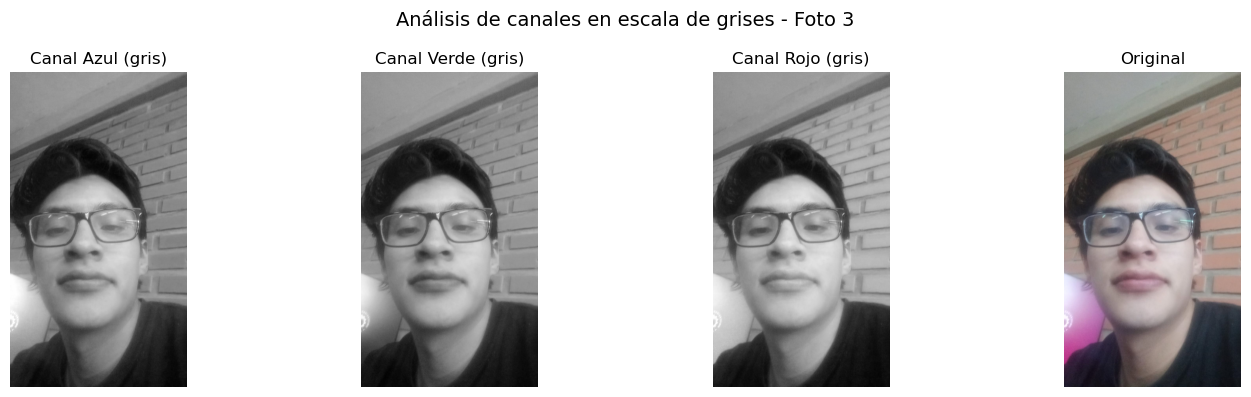


PROCESAMIENTO COMPLETADO


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def mostrar_imagenes(imagen_bgr, titulo_original, titulo_procesada, imagen_procesada, cmap_procesada='gray'):
    """
    Función para mostrar imágenes originales y procesadas
    
    Parámetros:
    imagen_bgr: imagen en formato BGR
    titulo_original: título para la imagen original
    titulo_procesada: título para la imagen procesada
    imagen_procesada: imagen procesada a mostrar
    cmap_procesada: mapa de color para la imagen procesada (default 'gray')
    """
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.title(titulo_original)
    plt.imshow(imagen_rgb)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title(titulo_procesada)
    plt.imshow(imagen_procesada, cmap=cmap_procesada)
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def mostrar_canales_color(imagen_bgr, titulo):
    """
    Muestra los diferentes canales de una imagen en su color correspondiente
    """
    b, g, r = cv2.split(imagen_bgr)
    
    height, width = b.shape
    canal_azul_color = np.zeros((height, width, 3), dtype=np.uint8)
    canal_verde_color = np.zeros((height, width, 3), dtype=np.uint8)
    canal_rojo_color = np.zeros((height, width, 3), dtype=np.uint8)
    
    
    canal_azul_color[:,:,0] = b 
    canal_verde_color[:,:,1] = g  
    canal_rojo_color[:,:,2] = r  
    
    plt.figure(figsize=(15, 4))
    

    plt.suptitle(f'Análisis de canales en color - {titulo}', fontsize=14)
    

    plt.subplot(1, 4, 1)
    plt.title('Canal Azul')
    plt.imshow(cv2.cvtColor(canal_azul_color, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title('Canal Verde')
    plt.imshow(cv2.cvtColor(canal_verde_color, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title('Canal Rojo')
    plt.imshow(cv2.cvtColor(canal_rojo_color, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    color_falso = cv2.merge([r, g, b])  
    plt.subplot(1, 4, 4)
    plt.title('Color Falso\n(Rojo<->Azul)')
    plt.imshow(cv2.cvtColor(color_falso, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

def mostrar_canales_gris(imagen_bgr, titulo):
    """
    Muestra los diferentes canales de una imagen en escala de grises
    (Versión alternativa en blanco y negro)
    """
 
    b, g, r = cv2.split(imagen_bgr)
    
    plt.figure(figsize=(15, 4))
    
 
    plt.suptitle(f'Análisis de canales en escala de grises - {titulo}', fontsize=14)
    

    plt.subplot(1, 4, 1)
    plt.title('Canal Azul (gris)')
    plt.imshow(b, cmap='gray')
    plt.axis('off')
    

    plt.subplot(1, 4, 2)
    plt.title('Canal Verde (gris)')
    plt.imshow(g, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title('Canal Rojo (gris)')
    plt.imshow(r, cmap='gray')
    plt.axis('off')
    

    plt.subplot(1, 4, 4)
    plt.title('Original')
    plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


print("PROCESANDO PRIMERA FOTOGRAFÍA...")
print("-" * 40)


img1 = cv2.imread('foto1.jpg')

if img1 is not None:

    cv2.imwrite('foto1_original_BGR.jpg', img1)
    print("✓ Imagen original BGR guardada como 'foto1_original_BGR.jpg'")
    

    img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    

    cv2.imwrite('foto1_grises.jpg', img1_gray)
    print("✓ Imagen en escala de grises guardada como 'foto1_grises.jpg'")
    
    mostrar_imagenes(img1, 'Imagen Original (RGB)', 'Imagen en Escala de Grises', img1_gray)
    
    mostrar_canales_color(img1, 'Foto 1')
    
    mostrar_canales_gris(img1, 'Foto 1')
else:
    print("✗ Error: No se pudo cargar la primera fotografía")


print("\nPROCESANDO SEGUNDA FOTOGRAFÍA...")
print("-" * 40)

img2 = cv2.imread('foto2.jpg')

if img2 is not None:
    cv2.imwrite('foto2_original_BGR.jpg', img2)
    print("✓ Imagen original BGR guardada como 'foto2_original_BGR.jpg'")
    
    img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    
    cv2.imwrite('foto2_grises.jpg', img2_gray)
    print("✓ Imagen en escala de grises guardada como 'foto2_grises.jpg'")
    

    mostrar_imagenes(img2, 'Imagen Original (RGB)', 'Imagen en Escala de Grises', img2_gray)
    
    mostrar_canales_color(img2, 'Foto 2')
    
    mostrar_canales_gris(img2, 'Foto 2')
else:
    print("✗ Error: No se pudo cargar la segunda fotografía")

print("\nPROCESANDO TERCERA FOTOGRAFÍA...")
print("-" * 40)

img3 = cv2.imread('foto3.jpg')

if img3 is not None:
    cv2.imwrite('foto3_original_BGR.jpg', img3)
    print("✓ Imagen original BGR guardada como 'foto3_original_BGR.jpg'")
    
    img3_gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
    
    cv2.imwrite('foto3_grises.jpg', img3_gray)
    print("✓ Imagen en escala de grises guardada como 'foto3_grises.jpg'")
    
    mostrar_imagenes(img3, 'Imagen Original (RGB)', 'Imagen en Escala de Grises', img3_gray)
    
    mostrar_canales_color(img3, 'Foto 3')
    mostrar_canales_gris(img3, 'Foto 3')
else:
    print("✗ Error: No se pudo cargar la tercera fotografía")

print("\n" + "="*40)
print("PROCESAMIENTO COMPLETADO")
print("="*40)